# FinBERT Sentiment Analysis on MD&A Sections

**Pipeline**

1. Load `after_stopword_removal` sheet from `mda_processed_sample.xlsx`
2. Reshape wide → long (one row = one sentence)
3. Run **pre-trained FinBERT** (`ProsusAI/finbert`) for inference — no fine-tuning, no artificial labels
4. Apply **Loughran-McDonald rule-based** classifier as a comparison baseline
5. Compare the two methods' sentiment distributions and agreement


## 1. Imports & Setup


In [ ]:
import warnings, re

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset as HFDataset

plt.rcParams["figure.dpi"] = 110
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Device   : {DEVICE}")


PyTorch  : 2.10.0
CUDA     : False
Device   : cpu


## 2. Load & Reshape the MD&A Dataset

The Excel file is **wide-format**: each row is one filing; columns `sent_1 … sent_N`
hold individual sentences (pre-tokenised, lowercased, comma-separated tokens — stopwords removed).
We melt it to **long-format** (one row = one sentence) and reconstruct readable text.


In [ ]:
EXCEL_PATH = "Data Preparation/mda_processed_sample.xlsx"
SHEET_NAME = "after_stopword_removal"
DOC_COL = "doc"

df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
print(f"Loaded: {df.shape[0]} documents, {df.shape[1]} columns")
df.head(2)

Loaded: 64 documents, 452 columns


,doc,sent_1,sent_2,sent_3,sent_4,sent_5,sent_6,sent_7,sent_8,sent_9,...,sent_442,sent_443,sent_444,sent_445,sent_446,sent_447,sent_448,sent_449,sent_450,sent_451
0,NVIDIA_10-K_2010-03-18_MDA.txt,"overview, helped, awaken, world, power, comput...","expertise, programmable, gpus, led, breakthrou...","serve, entertainment, consumer, market, geforc...","last, several, years, operated, reported, four...","however, effective, first_year, longer, separa...","gpu_business, comprised, primarily, geforce, p...","psb, comprised, quadro_professional, workstati...","mcp, business, reported, year, comprised, prim...","ion, family, products, addresses, integrated, ...",...,"although, number, units, estimate, impacted, i...","weak_diepackaging_material, combination, used,...","continue, seek, access, insurance, coverage, r...","however_assurance, made, aggregate, million, c...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,"overview, invented, graphics, processing, unit...","since, strived, new, standards, visual_computi...","expertise, programmable, gpus, computer-system...","strategically, investing, three, major, areas,...","serve, visual_computing, market, consumer, gef...","three, primary, financial, gpu, professional_s...","years, operated, reported, four, major, produc...","however, first_year, began, reporting, interna...","comparative, periods, presented, reflect, change",...,"recommended, customers, consider, changing, th...","intend, fully, support, custom, ers, repair, r...","weak_diepackaging_material, combination, used,...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ...",NaN


In [ ]:
sent_cols = [c for c in df.columns if c.startswith("sent_")]
print(f"Sent cols: {len(sent_cols)}")

# ── melt wide → long ─────────────────────────────────────────────────────────
long = (
    df.melt(
        id_vars=DOC_COL, value_vars=sent_cols, var_name="sent_col", value_name="tokens"
    )
    .dropna(subset=["tokens"])
    .reset_index(drop=True)
)

# Reconstruct sentence text: split comma-separated tokens → join with spaces
long["processed_text"] = long["tokens"].apply(lambda t: " ".join(str(t).split(", ")))

# Filter out very short fragments (< 6 words)
long = long[long["processed_text"].str.split().str.len() >= 6].reset_index(drop=True)


# ── parse metadata from doc name ──────────────────────────────────────────────
# Format: NVIDIA_10-K_2010-03-18_MDA.txt
def parse_doc(doc_name):
    parts = doc_name.replace("_MDA.txt", "").split("_")
    ticker = parts[0]
    filing_type = parts[1]  # 10-K or 10-Q
    date_str = parts[2]
    dt = pd.to_datetime(date_str)
    month = dt.month
    quarter = f"Q{(month - 1) // 3 + 1}"
    return ticker, filing_type, dt, str(dt.year), quarter


meta = long[DOC_COL].apply(
    lambda d: pd.Series(
        parse_doc(d), index=["ticker", "filing_type", "date", "year", "quarter"]
    )
)
long = pd.concat([long[[DOC_COL, "processed_text"]], meta], axis=1)

print(f"Total sentences : {len(long):,}")
print(f"Date range      : {long['date'].min().date()} → {long['date'].max().date()}")
print(f"Filing types    : {long['filing_type'].value_counts().to_dict()}")
print()
long.head(6)

Sent cols: 451
Total sentences : 10,243
Date range      : 2010-03-18 → 2025-11-19
Filing types    : {'10-Q': 6425, '10-K': 3818}



,doc,processed_text,ticker,filing_type,date,year,quarter
0,NVIDIA_10-K_2010-03-18_MDA.txt,overview helped awaken world power computer_gr...,NVIDIA,10-K,2010-03-18,2010,Q1
1,NVIDIA_10-K_2011-03-16_MDA.txt,overview invented graphics processing unit gpu,NVIDIA,10-K,2011-03-16,2011,Q1
2,NVIDIA_10-K_2012-03-13_MDA.txt,overview known millions around world creating ...,NVIDIA,10-K,2012-03-13,2012,Q1
3,NVIDIA_10-K_2013-03-12_MDA.txt,overview visual_computing connecting people po...,NVIDIA,10-K,2013-03-12,2013,Q1
4,NVIDIA_10-K_2015-03-12_MDA.txt,overview_businesses dedicated advancing visual...,NVIDIA,10-K,2015-03-12,2015,Q1
5,NVIDIA_10-K_2017-03-01_MDA.txt,overview_businesses starting focus_pc_graphics...,NVIDIA,10-K,2017-03-01,2017,Q1


In [ ]:
# Create a new df so that for each row, it'll show the document name and 1 sentence

rows = []

for _, row in df.iterrows():
    doc_name = row[DOC_COL]

    for sent_col in sent_cols:
        sentence = row[sent_col]

        if pd.notna(sentence) and str(sentence).strip() != "":
            rows.append(
                {
                    "doc": doc_name,
                    "sentence_id": sent_col,
                    "sentence": sentence,
                }
            )

long_df = pd.DataFrame(rows)

long_df["sentence_fixed"] = (
    long_df["sentence"]
    .astype(str)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(f"Total sentences: {len(long_df):,}")
long_df.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Corpus Overview — MD&A Sentences", fontsize=13, fontweight="bold")

# Sentences per filing
sents_per_doc = long_df.groupby("doc").size().reset_index(name="n_sentences")
axes[0].hist(sents_per_doc["n_sentences"], bins=20, color="#3498db", edgecolor="white")
axes[0].set_title("Sentences per Filing")
axes[0].set_xlabel("# sentences")
axes[0].set_ylabel("# filings")

# Sentences per year (merge date from df)
doc_dates = df[[DOC_COL]].copy()
doc_dates["date"] = df[DOC_COL].str.extract(r"_(\d{4}-\d{2}-\d{2})_")[0]
doc_dates["year"] = pd.to_datetime(doc_dates["date"]).dt.year
merged = long_df.merge(doc_dates, on=DOC_COL, how="left")
yr_counts = merged["year"].value_counts().sort_index()
axes[1].bar(
    yr_counts.index.astype(str), yr_counts.values, color="#9b59b6", edgecolor="white"
)
axes[1].set_title("Sentences per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# sentences")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Total filings  : {long_df['doc'].nunique()}")
print(f"Total sentences: {len(long_df):,}")
print(f"Avg per filing : {len(long_df) / long_df['doc'].nunique():.0f}")

## 2. Time-Based Stratified Train-Test Split

**Split rule**: filings dated **≤ 2022-12-31 → train**; **2023-01-01 + → test**.  
This ensures the model is always evaluated on unseen _future_ filings — no look-ahead bias.
Stratification is verified by checking label proportions in both halves.


In [ ]:
TRAIN_CUTOFF = pd.Timestamp("2022-12-31")

# Attach dates to long_df for the split
long_df_dated = long_df.merge(doc_dates[["doc", "date"]], on="doc", how="left")
long_df_dated["date"] = pd.to_datetime(long_df_dated["date"])

train_all = (
    long_df_dated[long_df_dated["date"] <= TRAIN_CUTOFF].copy().reset_index(drop=True)
)
test_all = (
    long_df_dated[long_df_dated["date"] > TRAIN_CUTOFF].copy().reset_index(drop=True)
)

print(f"Train (≤2022): {len(train_all):>6,} sentences")
print(f"Test  (2023+): {len(test_all):>6,} sentences")

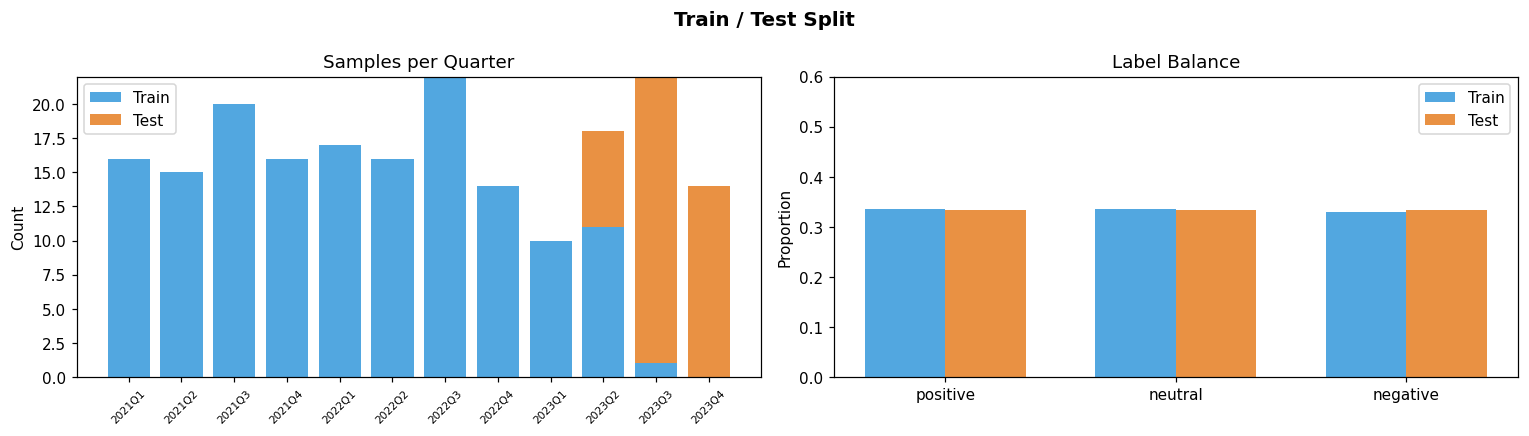

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Train / Test Split", fontsize=12, fontweight="bold")

all_years = sorted(long["year_int"].unique())
tr_yc = train_all["year_int"].value_counts()
te_yc = test_all["year_int"].value_counts()
tr_v = [tr_yc.get(y, 0) for y in all_years]
te_v = [te_yc.get(y, 0) for y in all_years]
x = range(len(all_years))

axes[0].bar(x, tr_v, label="Train", color="#3498db", alpha=0.85)
axes[0].bar(x, te_v, bottom=tr_v, label="Test", color="#e67e22", alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(all_years, rotation=45)
axes[0].set_title("Sentences per Year")
axes[0].set_ylabel("Count")
axes[0].legend()

LABELS_ORDER = ["positive", "neutral", "negative"]
tr_p = [
    train_all["sentiment_label"].value_counts(normalize=True).get(l, 0)
    for l in LABELS_ORDER
]
te_p = [
    test_all["sentiment_label"].value_counts(normalize=True).get(l, 0)
    for l in LABELS_ORDER
]
bx = np.arange(3)
w = 0.35
axes[1].bar(bx - w / 2, tr_p, w, label="Train", color="#3498db", alpha=0.85)
axes[1].bar(bx + w / 2, te_p, w, label="Test", color="#e67e22", alpha=0.85)
axes[1].set_xticks(bx)
axes[1].set_xticklabels(LABELS_ORDER)
axes[1].set_title("Label Balance — Train vs Test")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Stratified Sample for CPU-Friendly Training

The full dataset (~12 000 sentences) would require 30+ minutes per epoch on CPU.
We draw a **stratified sample** (1 500 train + 300 test) preserving label proportions.

> **To use the full data**: delete this cell and replace `train_df` / `test_df` with
> `train_all` / `test_all` below, then set `EPOCHS = 3` and run on a GPU.


In [ ]:
SAMPLE_SIZE = 500  # reduce for faster CPU inference; set None to use all

if SAMPLE_SIZE and len(long_df) > SAMPLE_SIZE:
    sample_df = long_df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
else:
    sample_df = long_df.copy()

print(f"Inference on {len(sample_df):,} sentences")

## 6. FinBERT Setup & Tokenisation


In [ ]:
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"positive": 0, "neutral": 1, "negative": 2}
ID2LABEL = {0: "positive", 1: "neutral", 2: "negative"}
MAX_LEN = 128
BATCH_SIZE = 32

print(f"Loading tokeniser & model: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
print("Ready.")

## 7. FinBERT Inference


In [ ]:
def finbert_predict(texts, batch_size=BATCH_SIZE):
    """Run FinBERT inference; returns (labels list, probs array)."""
    all_labels, all_probs = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).numpy()
        all_labels.extend([ID2LABEL[int(p)] for p in probs.argmax(axis=1)])
        all_probs.extend(probs.tolist())
    return all_labels, np.array(all_probs)


print("Running FinBERT inference...")
texts = sample_df["sentence_fixed"].tolist()
fb_labels, fb_probs = finbert_predict(texts)

sample_df = sample_df.copy()
sample_df["finbert_sentiment"] = fb_labels
sample_df["prob_positive"] = fb_probs[:, 0]
sample_df["prob_neutral"] = fb_probs[:, 1]
sample_df["prob_negative"] = fb_probs[:, 2]

print("Done.")
print(sample_df["finbert_sentiment"].value_counts())

## 8. FinBERT Results — Sentiment Distribution


In [ ]:
LABELS_ORDER = ["positive", "neutral", "negative"]
palette = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "FinBERT Sentiment — Pre-trained Inference", fontsize=13, fontweight="bold"
)

# Label distribution
vc = sample_df["finbert_sentiment"].value_counts().reindex(LABELS_ORDER, fill_value=0)
axes[0].bar(
    vc.index, vc.values, color=[palette[l] for l in vc.index], edgecolor="white"
)
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for i, (lbl, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha="center", fontweight="bold")

# Average confidence per class
avg_conf = pd.DataFrame(
    {
        "positive": [sample_df["prob_positive"].mean()],
        "neutral": [sample_df["prob_neutral"].mean()],
        "negative": [sample_df["prob_negative"].mean()],
    }
).T.rename(columns={0: "avg_prob"})
axes[1].bar(
    avg_conf.index,
    avg_conf["avg_prob"],
    color=[palette[l] for l in avg_conf.index],
    edgecolor="white",
)
axes[1].set_title("Average Confidence per Class")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Avg Probability")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(sample_df["finbert_sentiment"].value_counts(normalize=True).round(3).to_string())

## 9. Baseline: Loughran-McDonald Rule-Based Classifier


In [ ]:
# Agreement matrix between FinBERT and LM rule-based predictions
agree = pd.crosstab(
    sample_df["lm_sentiment"],
    sample_df["finbert_sentiment"],
    rownames=["LM (row)"],
    colnames=["FinBERT (col)"],
).reindex(index=LABELS_ORDER, columns=LABELS_ORDER, fill_value=0)

total_agree = sum(
    agree.loc[l, l] for l in LABELS_ORDER if l in agree.index and l in agree.columns
)
pct_agree = total_agree / len(sample_df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "LM Rule-Based vs FinBERT — Method Agreement", fontsize=13, fontweight="bold"
)

sns.heatmap(agree, annot=True, fmt="d", cmap="Blues", ax=axes[0], linewidths=0.5)
axes[0].set_title(f"Agreement Matrix  (overall {pct_agree:.1f}%)")

# Side-by-side distribution comparison
comp = pd.DataFrame(
    {
        "LM": sample_df["lm_sentiment"]
        .value_counts()
        .reindex(LABELS_ORDER, fill_value=0),
        "FinBERT": sample_df["finbert_sentiment"]
        .value_counts()
        .reindex(LABELS_ORDER, fill_value=0),
    }
)
comp.plot(
    kind="bar", ax=axes[1], color=["#3498db", "#e67e22"], edgecolor="white", width=0.7
)
axes[1].set_title("Prediction Distribution Comparison")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
LM_POSITIVE = {
    "achieve",
    "achievement",
    "advantage",
    "benefit",
    "best",
    "better",
    "boost",
    "confident",
    "deliver",
    "effective",
    "efficiency",
    "enhance",
    "exceed",
    "excellent",
    "exceptional",
    "expand",
    "favorable",
    "gain",
    "good",
    "grew",
    "growth",
    "high",
    "higher",
    "improve",
    "improved",
    "improvement",
    "increase",
    "increased",
    "innovative",
    "leading",
    "maximize",
    "opportunity",
    "outperform",
    "positive",
    "profit",
    "profitable",
    "progress",
    "record",
    "recover",
    "revenue",
    "rise",
    "robust",
    "strong",
    "stronger",
    "success",
    "successful",
    "surge",
    "sustainable",
    "upward",
}
LM_NEGATIVE = {
    "adverse",
    "challenge",
    "concern",
    "contraction",
    "costly",
    "decline",
    "decrease",
    "default",
    "deficit",
    "deteriorate",
    "difficult",
    "difficulty",
    "disappoint",
    "downturn",
    "drop",
    "failure",
    "fall",
    "fear",
    "impair",
    "impairment",
    "inability",
    "instability",
    "insufficient",
    "issue",
    "lag",
    "liability",
    "loss",
    "losses",
    "lower",
    "miss",
    "negative",
    "obstacle",
    "penalty",
    "poor",
    "problem",
    "recession",
    "reduce",
    "reduction",
    "restructure",
    "risk",
    "shortage",
    "slowdown",
    "struggle",
    "uncertain",
    "uncertainty",
    "unfavorable",
    "volatility",
    "weak",
    "weakness",
    "writedown",
}


def lm_classify(text):
    words = str(text).lower().split()
    pos = sum(w in LM_POSITIVE for w in words)
    neg = sum(w in LM_NEGATIVE for w in words)
    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"


sample_df["lm_sentiment"] = sample_df["sentence_fixed"].apply(lm_classify)
print(sample_df["lm_sentiment"].value_counts())

## 10. Method Comparison Summary


In [ ]:
fb_dist = (
    sample_df["finbert_sentiment"]
    .value_counts(normalize=True)
    .reindex(LABELS_ORDER, fill_value=0)
    .round(3)
)
lm_dist = (
    sample_df["lm_sentiment"]
    .value_counts(normalize=True)
    .reindex(LABELS_ORDER, fill_value=0)
    .round(3)
)

cmp = pd.DataFrame(
    {
        "Sentiment": LABELS_ORDER,
        "FinBERT %": (fb_dist.values * 100).round(1),
        "LM Dict %": (lm_dist.values * 100).round(1),
    }
)
cmp["Diff (pp)"] = (cmp["FinBERT %"] - cmp["LM Dict %"]).round(1)

print(cmp.to_string(index=False))
print(f"\nOverall agreement between methods: {pct_agree:.1f}%")